# Проект: классификация

In [636]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [637]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [638]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [639]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
job_counts = df['job'].value_counts()
print(job_counts)

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


### Задание 3

In [640]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
# ваш код
def clean_balance(value):
    if isinstance(value, str):
        # Убираем пробелы, знак $ и другие символы
        value = value.replace(' ', '').replace('$', '').strip()
        # Заменяем запятую на точку для корректного преобразования в float
        value = value.replace(',', '.')
        # Если строка пустая, возвращаем NaN
        if value == '':
            return np.nan
        try:
            return float(value)
        except ValueError:
            return np.nan
    return value

# Применяем преобразование
df['balance'] = df['balance'].apply(clean_balance)
df['balance'] = pd.to_numeric(df['balance'], errors='coerce')

# Вычисляем среднее значение
mean_balance = df['balance'].mean()
print(f"Среднее значение balance после преобразования: {mean_balance:.3f}")

Среднее значение balance после преобразования: 1529.129


### Задание 4

In [641]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
# Вычисляем медиану признака balance
balance_median = df['balance'].median()
print(f"Медианное значение balance: {balance_median:.3f}")

# Заменяем пропуски на медиану
df['balance'].fillna(balance_median, inplace=True)

# Проверяем, что пропусков больше нет
print(f"Количество пропусков после замены: {df['balance'].isnull().sum()}")

# Вычисляем новое среднее значение
new_mean_balance = df['balance'].mean()
print(f"Среднее значение balance после замены пропусков: {new_mean_balance:.3f}")

Медианное значение balance: 550.000
Количество пропусков после замены: 0
Среднее значение balance после замены пропусков: 1526.936


### Задание 5

In [642]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
# Находим модальные значения
job_mode = df['job'].mode()[0]
education_mode = df['education'].mode()[0]

print(f"Самая популярная работа (мода): {job_mode}")
print(f"Самый популярный уровень образования (мода): {education_mode}")

# Заменяем пропуски в job
df['job'] = df['job'].replace('unknown', job_mode)

# Заменяем пропуски в education
df['education'] = df['education'].replace('unknown', education_mode)

# Проверяем, что пропусков больше нет
print(f"\nКоличество значений 'unknown' в job после замены: {(df['job'] == 'unknown').sum()}")
print(f"Количество значений 'unknown' в education после замены: {(df['education'] == 'unknown').sum()}")

# Находим средний баланс для клиентов с самой популярной работой и самым популярным образованием
filtered_df = df[(df['job'] == job_mode) & (df['education'] == education_mode)]
mean_balance_filtered = filtered_df['balance'].mean()

print(f"\nСредний баланс для клиентов с работой '{job_mode}' и образованием '{education_mode}': {mean_balance_filtered:.3f}")

Самая популярная работа (мода): management
Самый популярный уровень образования (мода): secondary

Количество значений 'unknown' в job после замены: 0
Количество значений 'unknown' в education после замены: 0

Средний баланс для клиентов с работой 'management' и образованием 'secondary': 1598.883


### Задание 6

In [643]:
# Вычислите верхнюю и нижнюю границы поиска выбросов по методу Тьюки, округлив их до целых чисел.
# ваш код
# Вычисляем квартили для признака balance
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

# Вычисляем границы по методу Тьюки
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR (межквартильный размах): {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.0f}")
print(f"Верхняя граница: {upper_bound:.0f}")

Q1 (25-й перцентиль): 123.00
Q3 (75-й перцентиль): 1699.00
IQR (межквартильный размах): 1576.00
Нижняя граница: -2241
Верхняя граница: 4063


### Задание 7

In [644]:
# удалите все выбросы для признака balance
# ваш код
# Удаление выбросов из признака balance
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем данные
df = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)]

# Проверяем размер после удаления
print(f"Количество объектов после удаления выбросов: {len(df)}")

Количество объектов после удаления выбросов: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

Количество клиентов, открывших депозит (yes): 4681
Количество клиентов, не открывших депозит (no): 5424

Процент открывших депозит:    46.32%
Процент не открывших депозит: 53.68%


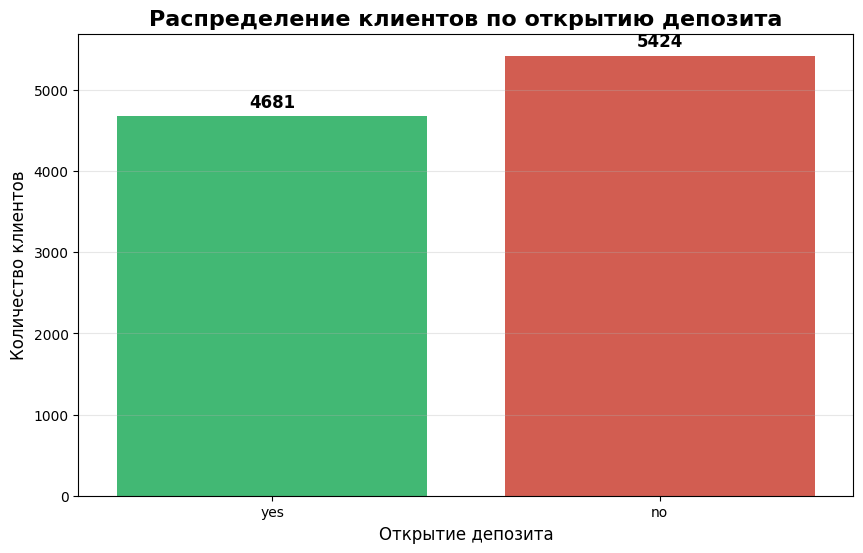

In [645]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# ваш код
# Изучаем распределение целевой переменной
deposit_counts = df['deposit'].value_counts()
print(f"Количество клиентов, открывших депозит (yes): {deposit_counts['yes']}")
print(f"Количество клиентов, не открывших депозит (no): {deposit_counts['no']}")
# Вычисляем процентное соотношение
total = len(df)
yes_percent = (deposit_counts['yes'] / total) * 100
no_percent = (deposit_counts['no'] / total) * 100
print(f"\nПроцент открывших депозит:    {yes_percent:.2f}%")
print(f"Процент не открывших депозит: {no_percent:.2f}%")

# Визуализация распределения
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c']
ax = sns.countplot(x='deposit', data=df, palette=colors)
plt.title('Распределение клиентов по открытию депозита', fontsize=16, fontweight='bold')
plt.xlabel('Открытие депозита', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

# Добавляем значения на столбцы
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

### Задания 2 и 3

In [646]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
# Выбираем количественные признаки
quantitative_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Рассчитываем описательные статистики
stats = df[quantitative_vars].describe()
print("Описательные статистики для количественных переменных:")
print(stats)

Описательные статистики для количественных переменных:
                age       balance           day      duration      campaign  \
count  10105.000000  10105.000000  10105.000000  10105.000000  10105.000000   
mean      40.895497    807.653538     15.590302    368.742603      2.517170   
std       11.734931    994.151966      8.441510    346.651524      2.707159   
min       18.000000  -2049.000000      1.000000      2.000000      1.000000   
25%       32.000000     95.000000      8.000000    137.000000      1.000000   
50%       38.000000    445.000000     15.000000    252.000000      2.000000   
75%       48.000000   1227.000000     22.000000    490.000000      3.000000   
max       95.000000   4063.000000     31.000000   3881.000000     43.000000   

              pdays      previous  
count  10105.000000  10105.000000  
mean      51.319644      0.816230  
std      109.644179      2.243795  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.0000

### Задания 4 и 5

In [647]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
# Выбираем категориальные признаки
categorical_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Рассчитываем описательные статистики для каждой категориальной переменной

for var in categorical_vars:
    print(f"\n--- {var.upper()} ---")
    print(f"Количество уникальных значений: {df[var].nunique()}")
    print("\nРаспределение значений:")
    print(df[var].value_counts())
    print(f"\nМода: {df[var].mode()[0]}")
    print(f"Частота моды: {df[var].value_counts().iloc[0]} ({df[var].value_counts().iloc[0] / len(df) * 100:.2f}%)")


--- JOB ---
Количество уникальных значений: 11

Распределение значений:
job
management       2315
blue-collar      1807
technician       1638
admin.           1246
services          868
retired           663
self-employed     358
unemployed        332
student           326
entrepreneur      300
housemaid         252
Name: count, dtype: int64

Мода: management
Частота моды: 2315 (22.91%)

--- MARITAL ---
Количество уникальных значений: 3

Распределение значений:
marital
married     5715
single      3213
divorced    1177
Name: count, dtype: int64

Мода: married
Частота моды: 5715 (56.56%)

--- EDUCATION ---
Количество уникальных значений: 3

Распределение значений:
education
secondary    5517
tertiary     3239
primary      1349
Name: count, dtype: int64

Мода: secondary
Частота моды: 5517 (54.60%)

--- DEFAULT ---
Количество уникальных значений: 2

Распределение значений:
default
no     9939
yes     166
Name: count, dtype: int64

Мода: no
Частота моды: 9939 (98.36%)

--- HOUSING ---
Кол

### Задание 6

In [648]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код

# Создаем сводную таблицу
cross_tab = pd.crosstab(df['poutcome'], df['deposit'])
print("Распределение результатов текущей кампании в зависимости от предыдущей:")
print(cross_tab)

# Добавляем процентные соотношения
cross_tab_percent = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
cross_tab_percent = cross_tab_percent.round(2)
print("\nПроцентное распределение:")
print(cross_tab_percent)

# Находим статус, где успех превалирует над неудачами
for status in cross_tab.index:
    yes_count = cross_tab.loc[status, 'yes']
    no_count = cross_tab.loc[status, 'no']
    diff = yes_count - no_count
    ratio = yes_count / no_count if no_count > 0 else float('inf')
    
# Находим статус с максимальным превалированием успеха
max_ratio_status = None
max_ratio = 0
for status in cross_tab.index:
    yes_count = cross_tab.loc[status, 'yes']
    no_count = cross_tab.loc[status, 'no']
    if no_count > 0:
        ratio = yes_count / no_count
        if ratio > max_ratio:
            max_ratio = ratio
            max_ratio_status = status

print(f"\nСтатус с максимальным превалированием успеха над неудачами: '{max_ratio_status}'")
print(f"Соотношение успехов к неудачам: {max_ratio:.2f}")
print(f"Количество успехов: {cross_tab.loc[max_ratio_status, 'yes']}")
print(f"Количество неудач: {cross_tab.loc[max_ratio_status, 'no']}")

Распределение результатов текущей кампании в зависимости от предыдущей:
deposit     no   yes
poutcome            
failure    562   547
other      216   265
success     84   861
unknown   4562  3008

Процентное распределение:
deposit      no    yes
poutcome              
failure   50.68  49.32
other     44.91  55.09
success    8.89  91.11
unknown   60.26  39.74

Статус с максимальным превалированием успеха над неудачами: 'success'
Соотношение успехов к неудачам: 10.25
Количество успехов: 861
Количество неудач: 84


### Задание 7

In [649]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код

# Создаем сводную таблицу: месяц vs результат
monthly_stats = pd.crosstab(df['month'], df['deposit'])

# Добавляем процент отказов для каждого месяца
monthly_stats['total'] = monthly_stats['no'] + monthly_stats['yes']
monthly_stats['refusal_rate'] = (monthly_stats['no'] / monthly_stats['total'] * 100).round(2)
monthly_stats['success_rate'] = (monthly_stats['yes'] / monthly_stats['total'] * 100).round(2)


# Находим месяц с самым высоким процентом отказов
max_refusal_month = monthly_stats['refusal_rate'].idxmax()
max_refusal_rate = monthly_stats.loc[max_refusal_month, 'refusal_rate']

print(f"МЕСЯЦ С САМЫМ ВЫСОКИМ ПРОЦЕНТОМ ОТКАЗОВ: {max_refusal_month}")
print(f"Процент отказов: {max_refusal_rate}%")
print(f"Количество отказов: {monthly_stats.loc[max_refusal_month, 'no']}")
print(f"Количество успехов: {monthly_stats.loc[max_refusal_month, 'yes']}")
print(f"Всего контактов: {monthly_stats.loc[max_refusal_month, 'total']}")

МЕСЯЦ С САМЫМ ВЫСОКИМ ПРОЦЕНТОМ ОТКАЗОВ: may
Процент отказов: 67.86%
Количество отказов: 1776
Количество успехов: 841
Всего контактов: 2617


### Задание 8

In [650]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
# Создание возрастных групп
bins = [18, 30, 40, 50, 60, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
# Создаем сводную таблицу
age_deposit = pd.crosstab(df['age_group'], df['deposit'])
print("Распределение результатов по возрастным группам:")
print(age_deposit)

# Добавляем процентные соотношения
age_deposit['total'] = age_deposit['no'] + age_deposit['yes']
age_deposit['success_rate'] = (age_deposit['yes'] / age_deposit['total'] * 100).round(2)
age_deposit['refusal_rate'] = (age_deposit['no'] / age_deposit['total'] * 100).round(2)

# Создаем столбец с соотношением только если нет деления на ноль
age_deposit['yes_no_ratio'] = age_deposit['yes'] / age_deposit['no'].replace(0, np.nan)
age_deposit['yes_no_ratio'] = age_deposit['yes_no_ratio'].round(2)
# Определяем группы, где успех превалирует над неудачами
for group in age_deposit.index:
    yes_count = age_deposit.loc[group, 'yes']
    no_count = age_deposit.loc[group, 'no']
    if yes_count > no_count:
        ratio = age_deposit.loc[group, 'yes_no_ratio']
        print(f"✅ {group}: Успехов {yes_count} > Неудач {no_count} (соотношение {ratio:.2f})")
    else:
        print(f"❌ {group}: Успехов {yes_count} < Неудач {no_count}")
# Находим группу с максимальным соотношением успех/неудача
max_ratio_group = age_deposit['yes_no_ratio'].idxmax()
max_ratio = age_deposit.loc[max_ratio_group, 'yes_no_ratio']

print(f"\nГруппа с максимальным соотношением успех/неудача: {max_ratio_group}")
print(f"Соотношение: {max_ratio:.2f}")
print(f"Успехов: {age_deposit.loc[max_ratio_group, 'yes']}")
print(f"Неудач: {age_deposit.loc[max_ratio_group, 'no']}")

Распределение результатов по возрастным группам:
deposit      no   yes
age_group            
<30         594   861
30-40      2245  1716
40-50      1444   938
50-60       984   670
60+         157   496
✅ <30: Успехов 861 > Неудач 594 (соотношение 1.45)
❌ 30-40: Успехов 1716 < Неудач 2245
❌ 40-50: Успехов 938 < Неудач 1444
❌ 50-60: Успехов 670 < Неудач 984
✅ 60+: Успехов 496 > Неудач 157 (соотношение 3.16)

Группа с максимальным соотношением успех/неудача: 60+
Соотношение: 3.16
Успехов: 496
Неудач: 157


### Задания 9 и 10

СФЕРА ЗАНЯТОСТИ С НАИБОЛЬШИМ ЧИСЛОМ КЛИЕНТОВ: management
Семейное положение с наибольшей склонностью к открытию депозита: single


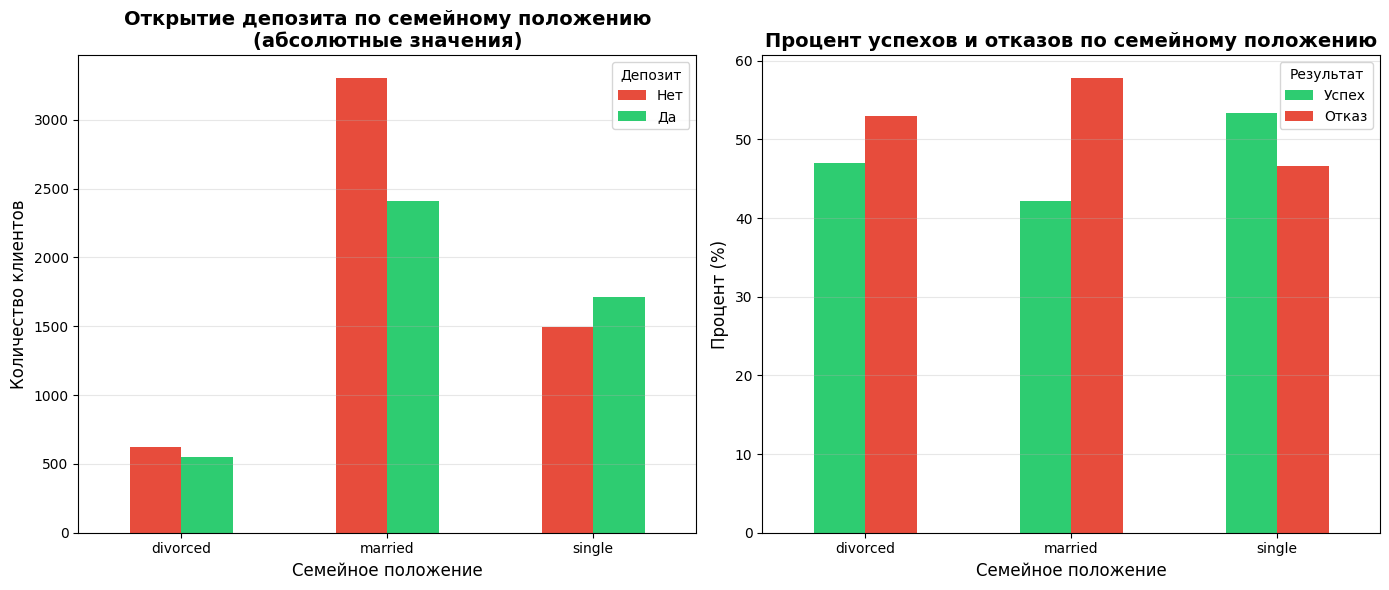

In [651]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
# СЕМЕЙНОЕ ПОЛОЖЕНИЕ (marital)

marital_stats = pd.crosstab(df['marital'], df['deposit'])
marital_stats['total'] = marital_stats['no'] + marital_stats['yes']
marital_stats['success_rate'] = (marital_stats['yes'] / marital_stats['total'] * 100).round(2)
marital_stats['refusal_rate'] = (marital_stats['no'] / marital_stats['total'] * 100).round(2)
marital_stats['yes_no_ratio'] = (marital_stats['yes'] / marital_stats['no']).round(2)
# Находим семейное положение с максимальной склонностью к открытию депозита
best_marital = marital_stats['yes_no_ratio'].idxmax()
best_ratio = marital_stats.loc[best_marital, 'yes_no_ratio']
best_rate = marital_stats.loc[best_marital, 'success_rate']

# УРОВЕНЬ ОБРАЗОВАНИЯ (education)
education_stats = pd.crosstab(df['education'], df['deposit'])
education_stats['total'] = education_stats['no'] + education_stats['yes']
education_stats['success_rate'] = (education_stats['yes'] / education_stats['total'] * 100).round(2)
education_stats['refusal_rate'] = (education_stats['no'] / education_stats['total'] * 100).round(2)

# СФЕРА ЗАНЯТОСТИ (job)
job_stats = pd.crosstab(df['job'], df['deposit'])
job_stats['total'] = job_stats['no'] + job_stats['yes']
job_stats['success_rate'] = (job_stats['yes'] / job_stats['total'] * 100).round(2)
job_stats['refusal_rate'] = (job_stats['no'] / job_stats['total'] * 100).round(2)
job_stats_sorted = job_stats.sort_values('total', ascending=False)
# Находим сферу занятости с наибольшим числом клиентов
top_job = job_stats_sorted.index[0]
top_job_count = job_stats_sorted.loc[top_job, 'total']

print(f"СФЕРА ЗАНЯТОСТИ С НАИБОЛЬШИМ ЧИСЛОМ КЛИЕНТОВ: {top_job}")
print(f"Семейное положение с наибольшей склонностью к открытию депозита: {best_marital}")

# ВИЗУАЛИЗАЦИИ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Семейное положение - абсолютные значения
marital_stats[['no', 'yes']].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Открытие депозита по семейному положению\n(абсолютные значения)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Семейное положение', fontsize=12)
axes[0].set_ylabel('Количество клиентов', fontsize=12)
axes[0].legend(title='Депозит', labels=['Нет', 'Да'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=0)

# Семейное положение - процентные соотношения
marital_stats[['success_rate', 'refusal_rate']].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Процент успехов и отказов по семейному положению', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Семейное положение', fontsize=12)
axes[1].set_ylabel('Процент (%)', fontsize=12)
axes[1].legend(title='Результат', labels=['Успех', 'Отказ'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

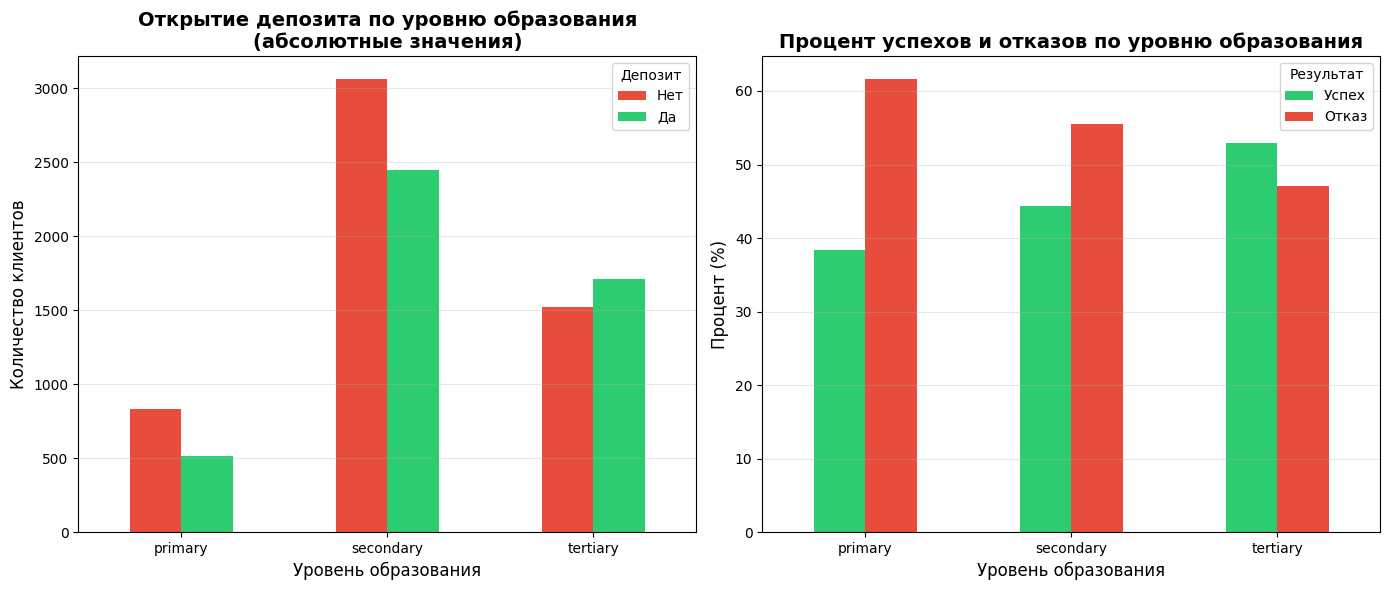

In [652]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Образование - абсолютные значения
education_stats[['no', 'yes']].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Открытие депозита по уровню образования\n(абсолютные значения)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Уровень образования', fontsize=12)
axes[0].set_ylabel('Количество клиентов', fontsize=12)
axes[0].legend(title='Депозит', labels=['Нет', 'Да'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=0)

# Образование - процентные соотношения
education_stats[['success_rate', 'refusal_rate']].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Процент успехов и отказов по уровню образования', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Уровень образования', fontsize=12)
axes[1].set_ylabel('Процент (%)', fontsize=12)
axes[1].legend(title='Результат', labels=['Успех', 'Отказ'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

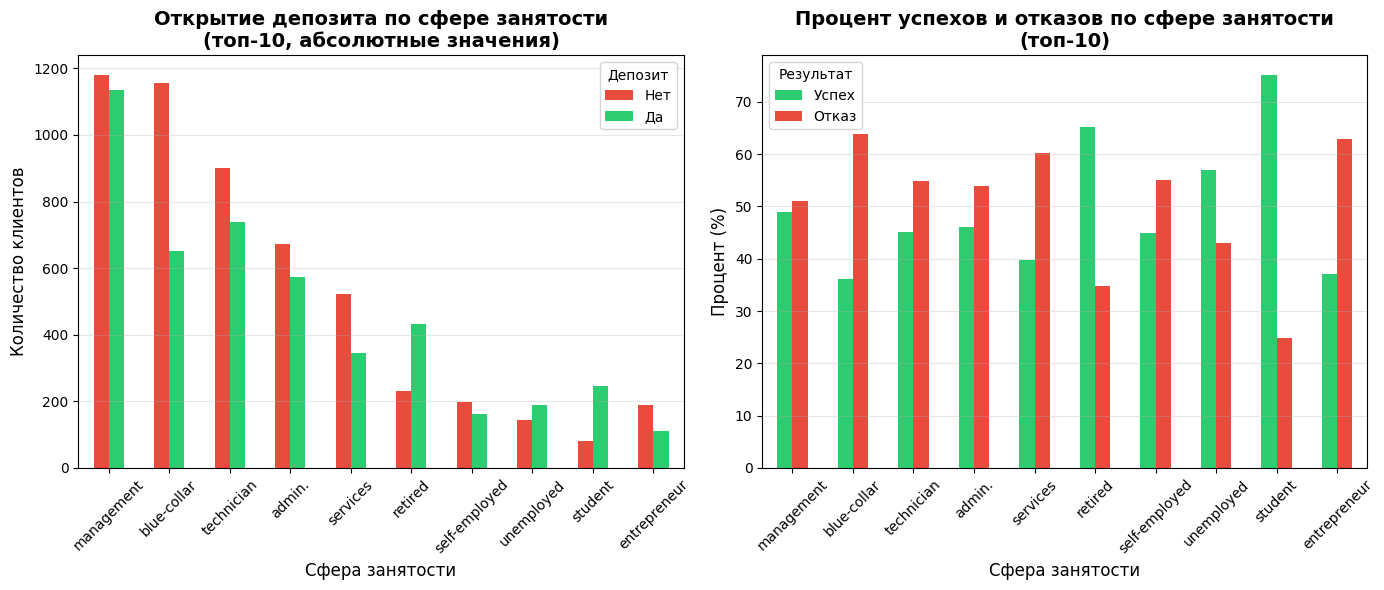

In [653]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Сфера занятости - абсолютные значения (топ-10)
top_10_jobs = job_stats_sorted.head(10)
top_10_jobs[['no', 'yes']].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Открытие депозита по сфере занятости\n(топ-10, абсолютные значения)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Сфера занятости', fontsize=12)
axes[0].set_ylabel('Количество клиентов', fontsize=12)
axes[0].legend(title='Депозит', labels=['Нет', 'Да'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Сфера занятости - процентные соотношения (топ-10)
top_10_jobs[['success_rate', 'refusal_rate']].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Процент успехов и отказов по сфере занятости\n(топ-10)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Сфера занятости', fontsize=12)
axes[1].set_ylabel('Процент (%)', fontsize=12)
axes[1].legend(title='Результат', labels=['Успех', 'Отказ'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Задание 11

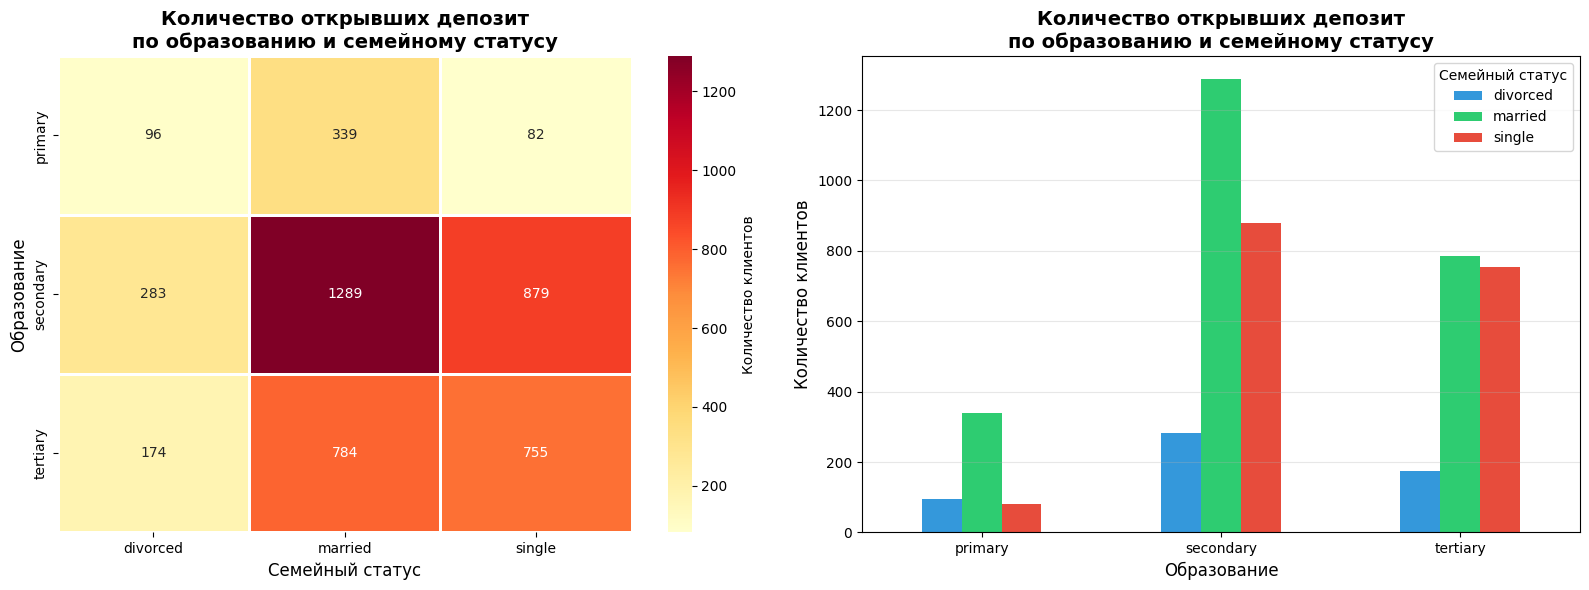

In [654]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
# Сводная таблица: образование и семейный статус для открывших депозит
deposit_yes = df[df['deposit'] == 'yes']
pivot_edu_marital = pd.crosstab(deposit_yes['education'], deposit_yes['marital'])

# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Тепловая карта
sns.heatmap(pivot_edu_marital, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], 
            linewidths=2, linecolor='white', cbar_kws={'label': 'Количество клиентов'})
axes[0].set_title('Количество открывших депозит\nпо образованию и семейному статусу', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Семейный статус', fontsize=12)
axes[0].set_ylabel('Образование', fontsize=12)

# График 2: Столбчатая диаграмма с группировкой
pivot_edu_marital.plot(kind='bar', ax=axes[1], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Количество открывших депозит\nпо образованию и семейному статусу', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Образование', fontsize=12)
axes[1].set_ylabel('Количество клиентов', fontsize=12)
axes[1].legend(title='Семейный статус')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Часть 3: преобразование данных

### Задание 1

In [655]:
# преобразуйте уровни образования
# Применяем LabelEncoder
le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['education'])

# Создаем DataFrame для наглядности
education_mapping = pd.DataFrame({
    'Original': df['education'].unique(),
    'Encoded': le.transform(df['education'].unique())
})

# Находим сумму закодированных значений (используем ПРАВИЛЬНЫЙ столбец)
sum_education_encoded = df['education_encoded'].sum()
print(f"Сумма закодированных значений для признака education: {sum_education_encoded}")

Сумма закодированных значений для признака education: 11995


### Задания 2 и 3

In [656]:
# преобразуйте бинарные переменные в представление из нулей и единиц
# Преобразование целевой переменной deposit в бинарный вид
# Преобразование целевой переменной deposit в бинарный вид
df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0})
# Вычисляем стандартное отклонение для преобразованного столбца
std_deposit = df['deposit_binary'].std()
print(f"Стандартное отклонение: {std_deposit:.3f}")
# Список бинарных переменных
binary_vars = ['default', 'housing', 'loan']

# Преобразуем каждую переменную
for var in binary_vars:
    df[var] = df[var].map({'yes': 1, 'no': 0})
# Вычисляем сумму средних
sum_means = df['default'].mean() + df['housing'].mean() + df['loan'].mean()
print(f"Среднее для default: {df['default'].mean():.4f}")
print(f"Среднее для housing: {df['housing'].mean():.4f}")
print(f"Среднее для loan: {df['loan'].mean():.4f}")
print(f"Сумма средних (округлено до 3 знаков): {sum_means:.3f}")

Стандартное отклонение: 0.499
Среднее для default: 0.0164
Среднее для housing: 0.4811
Среднее для loan: 0.1379
Сумма средних (округлено до 3 знаков): 0.635


### Задание 4

In [657]:
# Создаем dummy-переменные для номинальных переменных
nominal_vars = ['job', 'marital', 'contact', 'month', 'poutcome']

# Создаем dummy-переменные
dummies = pd.get_dummies(df[nominal_vars], prefix=nominal_vars, drop_first=False)

# Список столбцов, которые НЕ ЯВЛЯЮТСЯ признаками (целевые и служебные)
cols_to_exclude = ['deposit', 'deposit_binary', 'age_group'] 
# Считаем количество признаков: все столбцы df минус те, что в списке исключений
original_features = len([col for col in df.columns if col not in cols_to_exclude])

# Количество созданных dummy-переменных
dummy_count = dummies.shape[1]

# Общее количество признаков (исходные + dummy)
# Важно: не добавляем обратно столбцы из cols_to_exclude, так как мы их исключили
total_features = original_features + dummy_count

print(f"Общее количество признаков (исходные + dummy): {total_features}")

Общее количество признаков (исходные + dummy): 50


### Задания 5 и 6

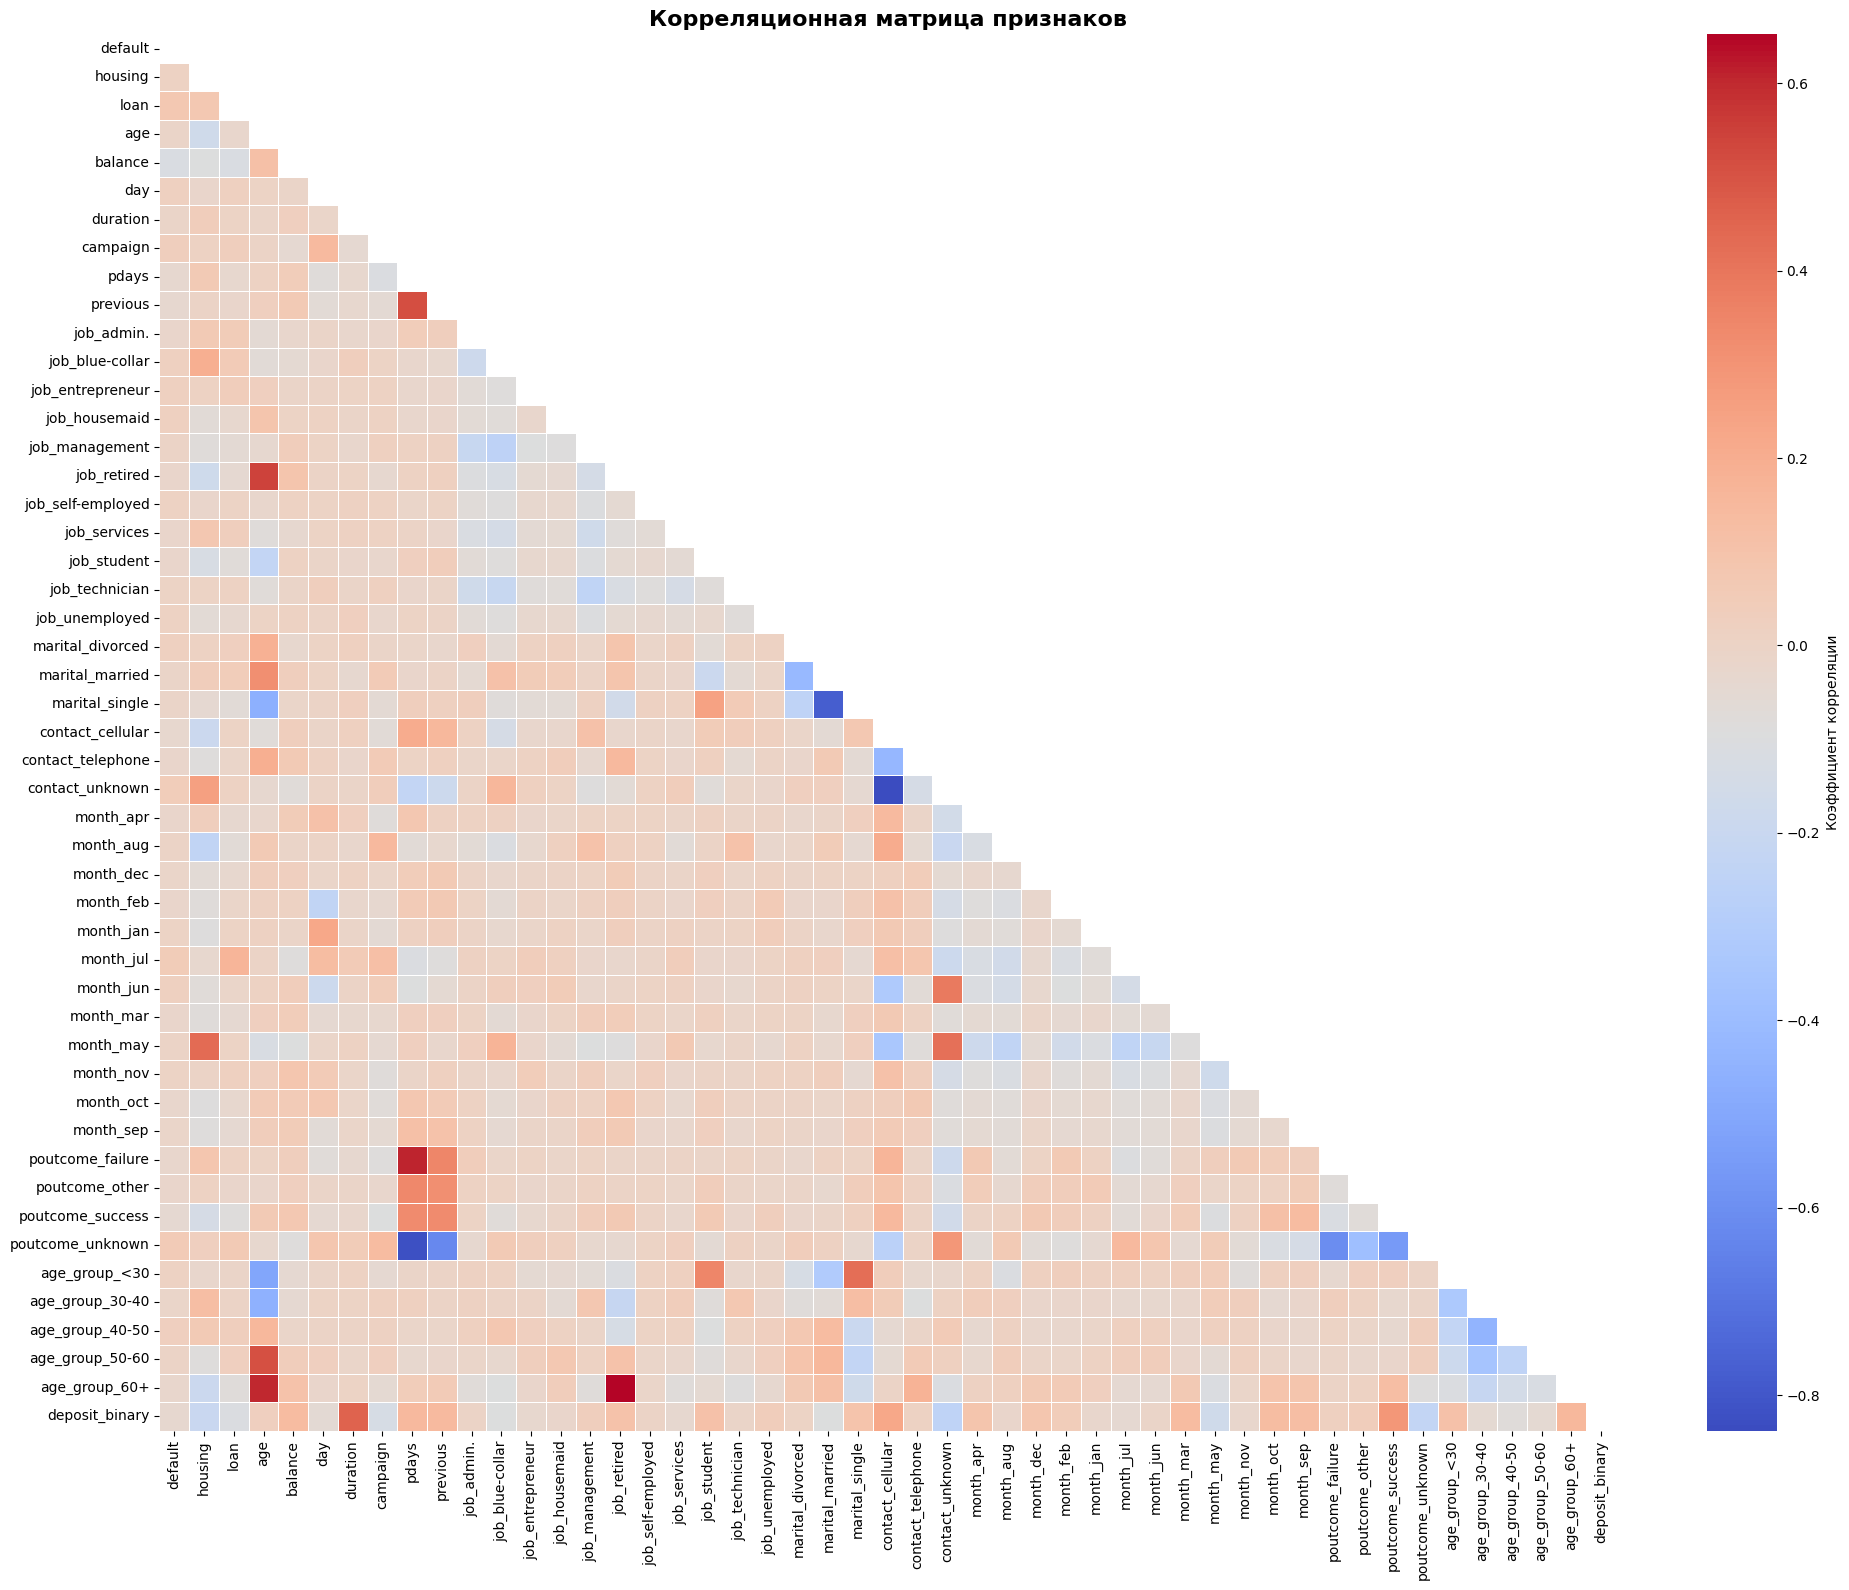


КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

Топ-20 признаков с наибольшей корреляцией с целевой переменной:
duration            0.4578
poutcome_success    0.2885
contact_cellular    0.2239
age_group_60+       0.1562
pdays               0.1479
previous            0.1411
balance             0.1359
month_mar           0.1353
month_oct           0.1306
month_sep           0.1252
age_group_<30       0.1057
job_student         0.1056
job_retired         0.1001
marital_single      0.0970
month_apr           0.0929
month_dec           0.0850
month_feb           0.0447
poutcome_other      0.0393
job_unemployed      0.0392
job_management      0.0296
Name: deposit_binary, dtype: float64


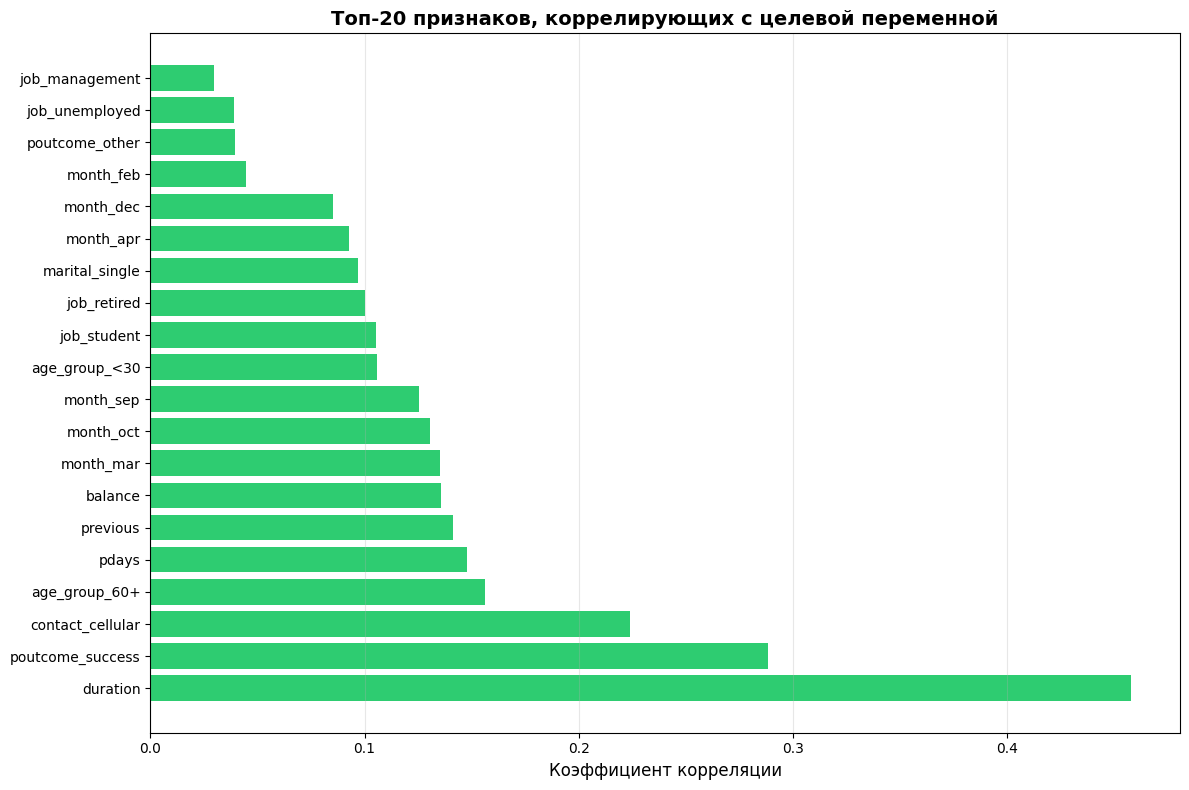

In [658]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
# Выбираем все числовые признаки (включая созданные dummy-переменные)
# Сначала создаем все необходимые переменные
# Определяем целевую переменную
if 'deposit_binary' in df.columns:
    target_var = 'deposit_binary'
elif 'deposit' in df.columns:
    # Если deposit еще строковый, преобразуем его
    if df['deposit'].dtype == 'object':
        df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0})
        target_var = 'deposit_binary'
    else:
        target_var = 'deposit'
else:
    # Если нет ни одного, создаем заново
    df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0})
    target_var = 'deposit_binary'

# Бинарные переменные уже преобразованы
binary_vars = ['default', 'housing', 'loan']

# Целевая переменная уже преобразована (deposit_binary)
target_var = 'deposit_binary' if 'deposit_binary' in df.columns else 'deposit'

# Количественные переменные
quant_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Создаем dummy-переменные для номинальных переменных
nominal_vars = ['job', 'marital', 'contact', 'month', 'poutcome']
dummies = pd.get_dummies(df[nominal_vars], prefix=nominal_vars, drop_first=False)

# Возрастные группы 
if 'age_group' in df.columns:
    age_group_dummies = pd.get_dummies(df['age_group'], prefix='age_group', drop_first=False)
else:
    age_group_dummies = pd.DataFrame()

# Собираем все признаки в один датафрейм
features = []
features.extend(binary_vars)
features.extend(quant_vars)

# Проверяем, что все признаки существуют в df
existing_features = [f for f in features if f in df.columns]
if len(existing_features) < len(features):
    print(f"Предупреждение: не все признаки найдены. Найдено: {existing_features}")


# Создаем датафрейм с признаками
df_corr = df[existing_features].copy()

# Добавляем dummy-переменные
df_corr = pd.concat([df_corr, dummies], axis=1)

# Добавляем возрастные группы
if not age_group_dummies.empty:
    df_corr = pd.concat([df_corr, age_group_dummies], axis=1)

# Добавляем целевую переменную
df_corr[target_var] = df[target_var]

# Если есть строковые столбцы, преобразуем их
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Удаляем столбцы с NaN (если такие появились)
df_corr = df_corr.dropna(axis=1, how='all')

# Вычисляем корреляционную матрицу
corr_matrix = df_corr.corr()


# Визуализация 1: Тепловая карта корреляционной матрицы
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            linewidths=0.5, cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Визуализация 2: Корреляция с целевой переменной (топ-20)
print("\n" + "=" * 70)
print("КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("=" * 70)

# Получаем корреляцию с целевой переменной
target_corr = corr_matrix[target_var].drop(target_var).sort_values(ascending=False)

# Выводим топ-20
print("\nТоп-20 признаков с наибольшей корреляцией с целевой переменной:")
print(target_corr.head(20).round(4))

# Визуализация 3: Столбчатая диаграмма ранжированных коэффициентов корреляции
plt.figure(figsize=(12, 8))
top_features = target_corr.head(20)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features.values]
bars = plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.title('Топ-20 признаков, коррелирующих с целевой переменной', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Задания 7 и 8

In [659]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [660]:
# рассчитайте необходимые показатели
# Размер тестовой выборки
print(f"Размер тестовой выборки: {len(y_test)}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
# Преобразуем y в числовой формат
if y.dtype == 'object' or y.dtype == 'string':
    y_numeric = y.map({'yes': 1, 'no': 0})
    # Заново разделяем данные с преобразованной целевой переменной
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_numeric, 
        stratify=y_numeric, 
        random_state=42, 
        test_size=0.33
    )
mean_y_test = y_test.mean()
print(f"Среднее значение (округлено до 2 знаков): {mean_y_test:.2f}")

Размер тестовой выборки: 3335
Размер тестовой выборки X_test: (3335, 19)
Среднее значение (округлено до 2 знаков): 0.46


### Задание 9

In [661]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
X = df.drop(['deposit', 'deposit_binary', 'age_group'], axis=1)
X_with_dummies = pd.concat([X, dummies], axis=1)

# Преобразуем все в числовой формат
for col in X_with_dummies.columns:
    if X_with_dummies[col].dtype == 'object':
        X_with_dummies[col] = pd.to_numeric(X_with_dummies[col], errors='coerce')

# Заполняем пропуски
X_with_dummies = X_with_dummies.fillna(X_with_dummies.mean())
X_with_dummies = X_with_dummies.fillna(0)

y = df['deposit_binary'].values

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_with_dummies, y,
    stratify=y,
    random_state=42,
    test_size=0.33
)

# Отбор 15 лучших признаков
k = min(15, X_train.shape[1])
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_features = selector.get_feature_names_out()

print(f"\nСписок отобранных признаков ({len(selected_features)}):")
print(selected_features.tolist())

month_features = [f for f in selected_features if f.startswith('month_')]
print(f"\nПеременные month_ в отобранных признаках: {month_features}")


Список отобранных признаков (15):
['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'contact_cellular', 'contact_unknown', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown']

Переменные month_ в отобранных признаках: ['month_mar', 'month_may', 'month_oct', 'month_sep']


### Задание 10

In [662]:
# нормализуйте данные с помощью minmaxsxaler
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

mean_value = X_test_scaled.iloc[:, 0].mean()
print(f"Среднее арифметическое (округлено до 2 знаков): {mean_value:.2f}")

Среднее арифметическое (округлено до 2 знаков): 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [673]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Обучаем логистическую регрессию
log_reg = LogisticRegression(
    solver='sag',
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

# Прогноз и accuracy
y_pred_log = log_reg.predict(X_test_scaled)
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Accuracy на тестовой выборке: {accuracy_log:.4f}")
print(f"Ответ (округлено до 2 знаков): {accuracy_log:.2f}")



Accuracy на тестовой выборке: 0.8042
Ответ (округлено до 2 знаков): 0.80


### Задания 2,3,4

In [690]:
from sklearn.tree import DecisionTreeClassifier
# обучите решающие деревья, настройте максимальную глубину
# Обучаем решающее дерево с параметрами по умолчанию
dt_default = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_default.fit(X_train_scaled, y_train)

# Оценка качества
y_train_pred_dt = dt_default.predict(X_train_scaled)
y_test_pred_dt = dt_default.predict(X_test_scaled)

train_acc_default = accuracy_score(y_train, y_train_pred_dt)
test_acc_default = accuracy_score(y_test, y_test_pred_dt)
print(f"Accuracy на обучающей выборке: {train_acc_default:.4f}")
print(f"Accuracy на тестовой выборке:  {test_acc_default:.4f}")

from sklearn.metrics import accuracy_score

# Перебираем различные глубины
max_depths = range(1, 31)
train_scores = []
test_scores = []

for depth in max_depths:
    dt = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=42
    )
    dt.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Находим оптимальную глубину 
best_test_acc = 0
best_depth = 1

for i, depth in enumerate(max_depths):
    diff = train_scores[i] - test_scores[i]
    if test_scores[i] > best_test_acc and diff <= 0.05:
        best_test_acc = test_scores[i]
        best_depth = depth

print(f"\nОптимальная глубина: {best_depth}")
print(f"Accuracy на тесте: {best_test_acc:.4f}")
print(f"Accuracy на обучении: {train_scores[best_depth-1]:.4f}")
print(f"ОТВЕТ: максимальная глубина = {best_depth}")

Accuracy на обучающей выборке: 0.9997
Accuracy на тестовой выборке:  0.7535

Оптимальная глубина: 7
Accuracy на тесте: 0.8045
Accuracy на обучении: 0.8232
ОТВЕТ: максимальная глубина = 7


### Задание 5

In [695]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
# Определяем модель
dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Создаем сетку параметров для перебора
param_grid = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth': [3, 5, 7]
}

# Создаем объект GridSearchCV
# scoring='f1' так как задание требует метрику F1
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',          # оптимизируем по F1
    cv=5,                  # 5-кратная кросс-валидация
    n_jobs=-1,             # используем все ядра
    verbose=1              # выводим прогресс
)

# Обучаем GridSearch на обучающей выборке
grid_search.fit(X_train_scaled, y_train)

# Получаем лучшие параметры
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Лучший F1 на кросс-валидации: {best_score:.2f}")

# Оценка на тестовой выборке
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_scaled)

# Вычисляем метрики на тесте
test_f1 = f1_score(y_test, y_pred_best)
print(f"F1-score: {test_f1:.2f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучший F1 на кросс-валидации: 0.80
F1-score: 0.78


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [700]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
# обучите на ваших данных случайный лес
# Обучаем случайный лес
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

# Прогноз
y_pred_rf = rf.predict(X_test_scaled)

# Метрики
accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f} -> {accuracy_rf:.2f}")
print(f"Recall:   {recall_rf:.4f} -> {recall_rf:.2f}")

Accuracy: 0.8273 -> 0.83
Recall:   0.8304 -> 0.83


### Задания 2 и 3

In [702]:
from sklearn.ensemble import GradientBoostingClassifier
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
# Обучаем градиентный бустинг с заданными параметрами
gb = GradientBoostingClassifier(
    learning_rate=0.05,      # скорость обучения
    n_estimators=300,        # количество деревьев
    min_samples_leaf=5,      # минимальное количество образцов в листе
    max_depth=5,             # максимальная глубина дерева
    random_state=42,         # для воспроизводимости
    verbose=1                # выводим прогресс обучения
)

# Обучаем модель
gb.fit(X_train_scaled, y_train)

# Прогноз на тестовой выборке
y_pred_gb = gb.predict(X_test_scaled)

# Вычисляем метрики
f1_gb = f1_score(y_test, y_pred_gb)
print(f"F1-score:  {f1_gb:.2f}")

      Iter       Train Loss   Remaining Time 
         1           1.3359            2.16s
         2           1.2948            2.29s
         3           1.2575            2.32s
         4           1.2237            2.28s
         5           1.1926            2.26s
         6           1.1643            2.23s
         7           1.1379            2.20s
         8           1.1134            2.20s
         9           1.0908            2.20s
        10           1.0694            2.19s
        20           0.9192            2.11s
        30           0.8367            2.02s
        40           0.7861            1.96s
        50           0.7523            1.88s
        60           0.7289            1.81s
        70           0.7129            1.73s
        80           0.6984            1.66s
        90           0.6872            1.58s
       100           0.6767            1.51s
       200           0.6087            0.72s
       300           0.5571            0.00s
F1-score:

### Задание 4

In [707]:
# объедините уже известные вам алгоритмы с помощью стекинга 
from sklearn.ensemble import StackingClassifier
# Определяем базовые модели (алгоритмы первого уровня)
base_learners = [
    ('dt', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=7,          
        min_samples_split=2,   
        random_state=42
    )),
    ('lr', LogisticRegression(
        solver='sag',
        random_state=42,
        max_iter=1000
    )),
    ('gb', GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
    ))
]

# Метамодель - логистическая регрессия
meta_model = LogisticRegression(
    solver='sag',
    random_state=42,
    max_iter=1000
)

# Создаем стекинг-классификатор
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5,                    
    n_jobs=-1,             
    verbose=1                
)

# Обучаем стек-модель
stacking_clf.fit(X_train_scaled, y_train)

# Прогноз на тестовой выборке
y_pred_stack = stacking_clf.predict(X_test_scaled)

# Вычисляем метрики
precision_stack = precision_score(y_test, y_pred_stack)
print(f"Precision: {precision_stack:.2f}")

Precision: 0.81


### Задание 5

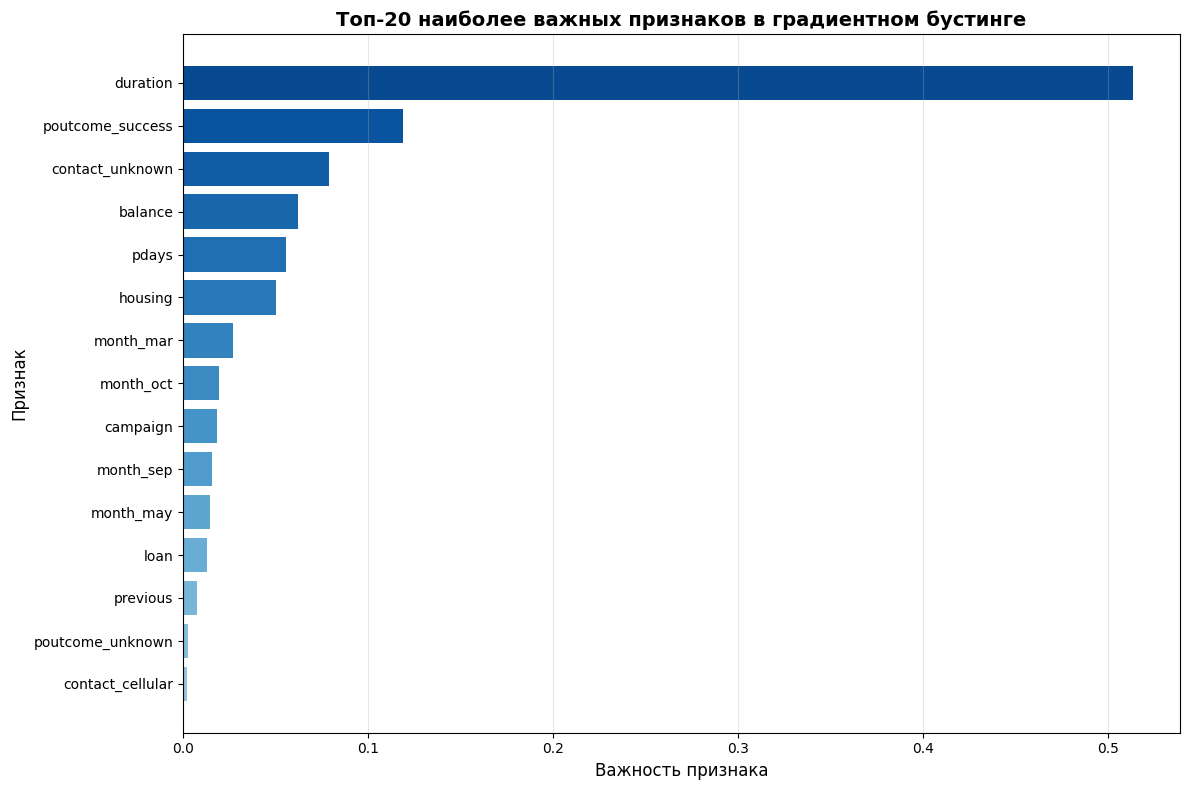

In [708]:
import pandas as pd
import matplotlib.pyplot as plt
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
feature_importance = gb.feature_importances_

# Создаем DataFrame для наглядности
feature_importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
plt.figure(figsize=(12, 8))

# Топ-20 признаков
top_20 = feature_importance_df.head(20)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_20)))[::-1]

plt.barh(top_20['feature'], top_20['importance'], color=colors)
plt.xlabel('Важность признака', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Топ-20 наиболее важных признаков в градиентном бустинге', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Задания 6,7,8

In [716]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

def objective(trial):
    """
    Целевая функция для Optuna.
    Оптимизируем гиперпараметры случайного леса.
    """
    # Предлагаем гиперпараметры для оптимизации
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)
    
    # Создаем модель с предложенными параметрами
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    # Обучаем модель на обучающей выборке
    rf.fit(X_train_scaled, y_train)
    
    # Делаем прогноз на тестовой выборке
    y_pred = rf.predict(X_test_scaled)
    
    # Возвращаем accuracy на тестовой выборке (максимизируем)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Создаем объект Optuna study для максимизации accuracy
study = optuna.create_study(
    direction='maximize',  # максимизируем accuracy
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE sampler для эффективного поиска
    study_name='random_forest_optimization'
)

# Запускаем оптимизацию (количество итераций)
n_trials = 50 
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

# Лучшие параметры
best_params = study.best_params
best_value = study.best_value
# Обучаем модель с лучшими параметрами
best_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_scaled, y_train)

# Прогноз на тестовой выборке
y_pred_best_rf = best_rf.predict(X_test_scaled)

# Метрики
best_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_f1 = f1_score(y_test, y_pred_best_rf)
print(f"Accuracy: {best_accuracy:.2f}")
print(f"F1-score: {best_f1:.2f}")

[I 2026-07-09 17:52:11,956] A new study created in memory with name: random_forest_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-09 17:52:12,147] Trial 0 finished with value: 0.824887556221889 and parameters: {'n_estimators': 137, 'max_depth': 29, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.824887556221889.
[I 2026-07-09 17:52:12,375] Trial 1 finished with value: 0.8254872563718141 and parameters: {'n_estimators': 160, 'max_depth': 13, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8254872563718141.
[I 2026-07-09 17:52:12,526] Trial 2 finished with value: 0.8245877061469266 and parameters: {'n_estimators': 105, 'max_depth': 28, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.8254872563718141.
[I 2026-07-09 17:52:12,749] Trial 3 finished with value: 0.8272863568215892 and parameters: {'n_estimators': 171, 'max_depth': 10, 'min_samples_leaf': 10}. Best is trial 3 with value: 0.8272863568215892.
[I 2026-07-09 17:52:12,991] Trial 4 finished with value: 0.8272863568215892 and parameters: {'n_estimators': 184, 'max_depth': 14, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.8272